# Hicks-Ray CSTR: the infinite horizon vs a long finite horizon

The model is the canonical declared Hicks-Ray CSTR from
[`models/hicks.py`](models/hicks.py): see the module for its construction.
Two cases of the same model. Case 1 runs five sampling steps with the
infinite-horizon terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.hicks import hicks
from plotting import plot_states, plot_controls, plot_stage_cost

m1 = hicks(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmp7h_6bt0u.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp7h_6bt0u.pyomo.nl...
Parsed 177 vars, 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 145, 'Number of variables': 177, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.8390681743621826}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

horizon,"t (ContinuousSet, 16 points)"
states,"zc (free), zt (free)"
dynamics,dzc[t] == (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t]) for t in t
dynamics,dzt[t] == (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw) for t in t
controls,"v1 (piecewise_constant, free), v2 (piecewise_constant, free)"
tracking stage cost,cost[t] == 10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2 for t in sorted(t)[:-1]
terminal cost,term == 10*(zc[5] - zc_ss)**2 + 2*(zt[5] - zt_ss)**2
initial conditions,zc[0] == zc_hat
initial conditions,zt[0] == zt_hat
steady-state targets,"zc_ss (of zc), zt_ss (of zt)"
steady-state control targets,"v1_ss (of v1), v2_ss (of v2)"


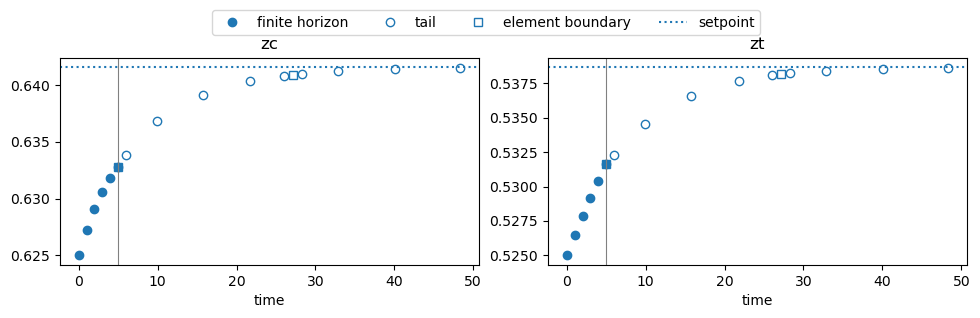

In [3]:
plot_states(m1);

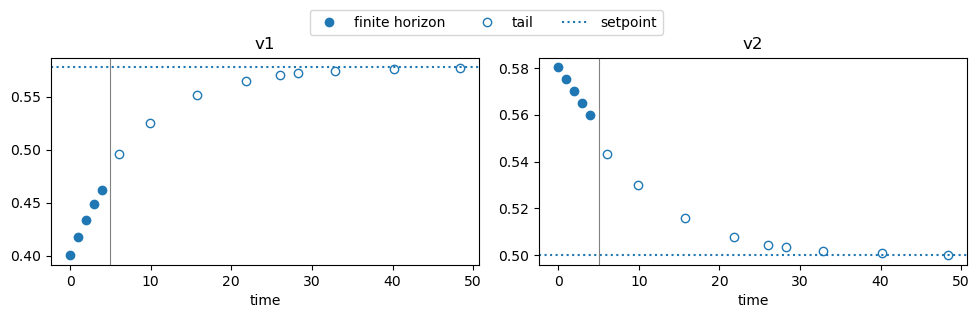

In [4]:
plot_controls(m1);

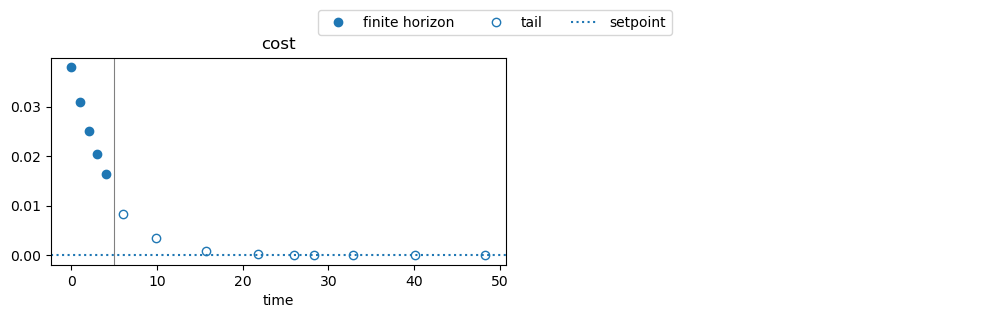

In [5]:
plot_stage_cost(m1);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = hicks(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpmz91o131.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpmz91o131.pyomo.nl...
Parsed 755 vars, 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 655, 'Number of variables': 755, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.8360912799835205}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

horizon,"t (ContinuousSet, 151 points)"
states,"zc (free), zt (free)"
dynamics,dzc[t] == (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t]) for t in t
dynamics,dzt[t] == (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw) for t in t
controls,"v1 (piecewise_constant, free), v2 (piecewise_constant, free)"
tracking stage cost,cost[t] == 10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2 for t in sorted(t)[:-1]
terminal cost,term == 10*(zc[50] - zc_ss)**2 + 2*(zt[50] - zt_ss)**2
initial conditions,zc[0] == zc_hat
initial conditions,zt[0] == zt_hat
steady-state targets,"zc_ss (of zc), zt_ss (of zt)"
steady-state control targets,"v1_ss (of v1), v2_ss (of v2)"


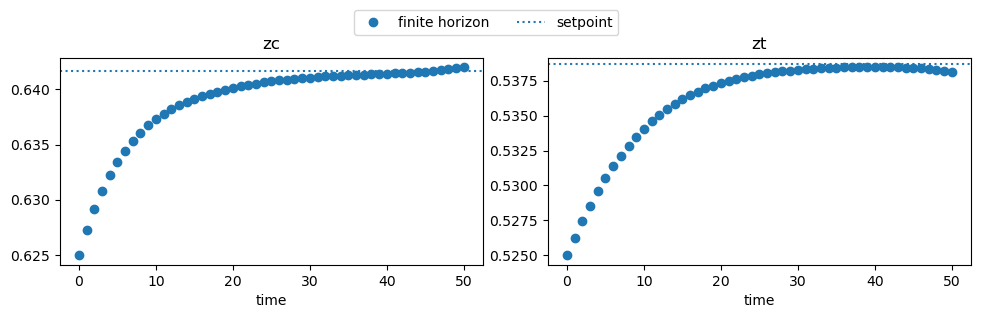

In [8]:
plot_states(m2);

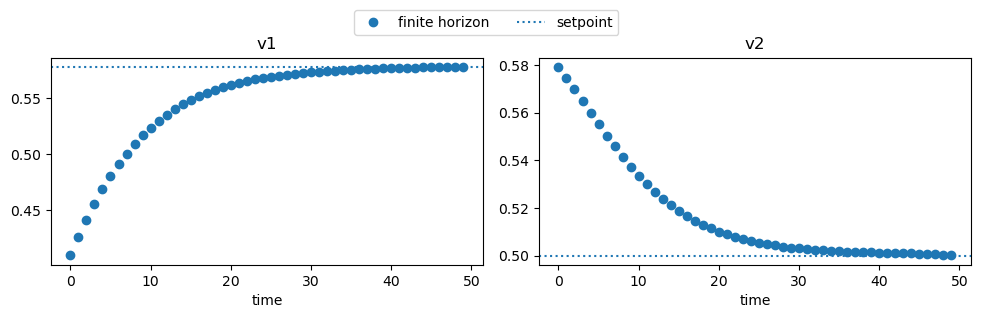

In [9]:
plot_controls(m2);

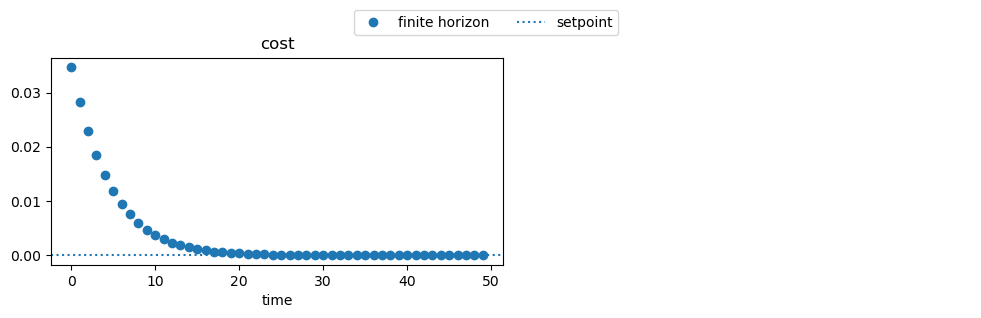

In [10]:
plot_stage_cost(m2);